In [1]:
import pandas as pd

In [2]:
customers = pd.read_csv("../data/customers.csv")
transactions = pd.read_csv("../data/transactions.csv")

In [3]:
customers.head()


,Customer_ID,Age,Occupation,Monthly_Income,Home_City,Usual_Device,Average_Transaction
0,CUST0001,19,Student,19012,Hyderabad,iPhone,585
1,CUST0002,61,Student,27870,Mumbai,MacBook,365
2,CUST0003,23,Student,17164,Hyderabad,Android,1449
3,CUST0004,63,Salaried,115181,Jaipur,MacBook,2605
4,CUST0005,55,Freelancer,61463,Delhi,iPhone,4162


In [4]:
transactions.head()

,Transaction_ID,Customer_ID,Amount,Hour,Location,Device,Merchant,Is_International,Transactions_Last_1H,Fraud
0,TXN000001,CUST0504,1322,15,Delhi,MacBook,Grocery,No,4,0
1,TXN000002,CUST0783,1627,0,Jaipur,MacBook,Shopping,No,2,1
2,TXN000003,CUST0950,3087,14,Lucknow,MacBook,Travel,No,4,0
3,TXN000004,CUST0909,18721,7,Chennai,Android,Crypto,No,3,0
4,TXN000005,CUST0404,667,19,Kolkata,Unknown,Grocery,No,5,1


In [5]:
customers.shape


(1000, 7)

In [6]:
transactions.shape

(51000, 10)

In [7]:
transactions.duplicated().sum()

np.int64(996)

In [8]:
transactions = transactions.drop_duplicates()

In [9]:
transactions.shape

(50004, 10)

In [10]:
transactions.isnull().sum()

Transaction_ID             0
Customer_ID                0
Amount                     0
Hour                       0
Location                   0
Device                  1500
Merchant                1501
Is_International           0
Transactions_Last_1H       0
Fraud                      0
dtype: int64

In [11]:
transactions["Device"] = transactions["Device"].fillna("Unknown")

In [12]:
transactions["Merchant"] = transactions["Merchant"].fillna("Unknown")

In [13]:
transactions.isnull().sum()

Transaction_ID          0
Customer_ID             0
Amount                  0
Hour                    0
Location                0
Device                  0
Merchant                0
Is_International        0
Transactions_Last_1H    0
Fraud                   0
dtype: int64

In [14]:
transactions["Fraud"].value_counts()

Fraud
0    48910
1     1094
Name: count, dtype: int64

In [15]:
# We use SMOTE to oversample the minority class (fraudulent transactions) in the training set. This will help the model learn to identify fraudulent transactions more effectively.

In [16]:
transactions.dtypes

Transaction_ID            str
Customer_ID               str
Amount                  int64
Hour                    int64
Location                  str
Device                    str
Merchant                  str
Is_International          str
Transactions_Last_1H    int64
Fraud                   int64
dtype: object

In [17]:
transactions.drop("Transaction_ID", axis=1)

,Customer_ID,Amount,Hour,Location,Device,Merchant,Is_International,Transactions_Last_1H,Fraud
0,CUST0504,1322,15,Delhi,MacBook,Grocery,No,4,0
1,CUST0783,1627,0,Jaipur,MacBook,Shopping,No,2,1
2,CUST0950,3087,14,Lucknow,MacBook,Travel,No,4,0
3,CUST0909,18721,7,Chennai,Android,Crypto,No,3,0
4,CUST0404,667,19,Kolkata,Unknown,Grocery,No,5,1
...,...,...,...,...,...,...,...,...,...
49999,CUST0124,1290,21,Bengaluru,MacBook,Crypto,No,2,0
50210,CUST0990,59740,1,Pune,Windows,Unknown,No,5,0
50258,CUST0077,1587,20,Lucknow,MacBook,Travel,No,4,0
50271,CUST0596,24760,15,Kolkata,Windows,Shopping,No,3,0


In [18]:
df = transactions.merge(customers, on="Customer_ID", how="left")

In [19]:
df.head()

,Transaction_ID,Customer_ID,Amount,Hour,Location,Device,Merchant,Is_International,Transactions_Last_1H,Fraud,Age,Occupation,Monthly_Income,Home_City,Usual_Device,Average_Transaction
0,TXN000001,CUST0504,1322,15,Delhi,MacBook,Grocery,No,4,0,21,Retired,43529,Delhi,MacBook,1059
1,TXN000002,CUST0783,1627,0,Jaipur,MacBook,Shopping,No,2,1,43,Retired,55202,Jaipur,Android,1748
2,TXN000003,CUST0950,3087,14,Lucknow,MacBook,Travel,No,4,0,65,Retired,36651,Lucknow,MacBook,2332
3,TXN000004,CUST0909,18721,7,Chennai,Android,Crypto,No,3,0,26,Business,267484,Chennai,Android,10628
4,TXN000005,CUST0404,667,19,Kolkata,Unknown,Grocery,No,5,1,29,Student,27604,Kolkata,iPhone,756


In [20]:
df["Transaction_Ratio"] = df["Amount"] / df["Average_Transaction"]

In [21]:
df[["Amount", "Average_Transaction", "Transaction_Ratio"]].head()

,Amount,Average_Transaction,Transaction_Ratio
0,1322,1059,1.248347
1,1627,1748,0.930778
2,3087,2332,1.323756
3,18721,10628,1.761479
4,667,756,0.882275


In [22]:
df["New_Device"] = (df["Device"] != df["Usual_Device"]).astype(int)

In [23]:
df[["Device", "Usual_Device", "New_Device"]].head(10)

,Device,Usual_Device,New_Device
0,MacBook,MacBook,0
1,MacBook,Android,1
2,MacBook,MacBook,0
3,Android,Android,0
4,Unknown,iPhone,1
5,iPhone,iPhone,0
6,MacBook,MacBook,0
7,MacBook,MacBook,0
8,Unknown,MacBook,1
9,MacBook,MacBook,0


In [24]:
df.describe()

,Amount,Hour,Transactions_Last_1H,Fraud,Age,Monthly_Income,Average_Transaction,Transaction_Ratio,New_Device
count,50004.000000,50004.000000,50004.000000,50004.000000,50004.000000,50004.000000,50004.000000,50004.000000,50004.000000
mean,4606.148748,11.497100,2.995740,0.021878,44.301576,83372.020618,4420.902048,1.042172,0.107971
std,8685.197011,6.932847,1.412658,0.146287,15.251803,70923.300696,4775.011166,1.049297,0.310347
min,100.000000,0.000000,1.000000,0.000000,18.000000,10482.000000,308.000000,0.005008,0.000000
25%,1037.000000,5.000000,2.000000,0.000000,31.000000,29142.000000,1251.000000,0.661246,0.000000
50%,2254.000000,12.000000,3.000000,0.000000,45.000000,61823.000000,2561.000000,1.001665,0.000000
75%,5180.000000,18.000000,4.000000,0.000000,57.000000,100311.000000,4942.000000,1.340873,0.000000
max,525900.000000,23.000000,5.000000,1.000000,70.000000,297240.000000,19970.000000,44.826117,1.000000


In [25]:
df["Location_Mismatch"] = (df["Location"] != df["Home_City"]).astype(int)

In [26]:
df["Night_Transaction"] = df["Hour"].between(0, 5).astype(int)

In [27]:
df[["Hour", "Night_Transaction"]].head(10)

,Hour,Night_Transaction
0,15,0
1,0,1
2,14,0
3,7,0
4,19,0
5,1,1
6,12,0
7,14,0
8,13,0
9,20,0


In [28]:
df.nunique()

Transaction_ID          50000
Customer_ID              1000
Amount                  13547
Hour                       24
Location                   14
Device                      5
Merchant                    9
Is_International            2
Transactions_Last_1H        5
Fraud                       2
Age                        53
Occupation                  5
Monthly_Income           1000
Home_City                  10
Usual_Device                4
Average_Transaction       935
Transaction_Ratio       48043
New_Device                  2
Location_Mismatch           2
Night_Transaction           2
dtype: int64

In [29]:
X = df.drop(columns=["Fraud", "Transaction_ID", "Customer_ID"])

y = df["Fraud"]

In [30]:
X.select_dtypes(include="object").columns

C:\Users\sumit\AppData\Local\Temp\ipykernel_10524\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['Location', 'Device', 'Merchant', 'Is_International', 'Occupation',
       'Home_City', 'Usual_Device'],
      dtype='str')

In [31]:
X["Is_International"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [32]:
X["Is_International"] = X["Is_International"].map({
    "No": 0,
    "Yes": 1
})

In [33]:
# One-hot encode categorical variables


In [34]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [35]:
categorical_cols = [
    "Location",
    "Device",
    "Merchant",
    "Occupation",
    "Home_City",
    "Usual_Device"
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [36]:
print(X.shape)
X.head()

(50004, 52)


,Amount,Hour,Is_International,Transactions_Last_1H,Age,Monthly_Income,Average_Transaction,Transaction_Ratio,New_Device,Location_Mismatch,...,Home_City_Delhi,Home_City_Hyderabad,Home_City_Jaipur,Home_City_Kolkata,Home_City_Lucknow,Home_City_Mumbai,Home_City_Pune,Usual_Device_MacBook,Usual_Device_Windows,Usual_Device_iPhone
0,1322,15,0,4,21,43529,1059,1.248347,0,0,...,True,False,False,False,False,False,False,True,False,False
1,1627,0,0,2,43,55202,1748,0.930778,1,0,...,False,False,True,False,False,False,False,False,False,False
2,3087,14,0,4,65,36651,2332,1.323756,0,0,...,False,False,False,False,True,False,False,True,False,False
3,18721,7,0,3,26,267484,10628,1.761479,0,0,...,False,False,False,False,False,False,False,False,False,False
4,667,19,0,5,29,27604,756,0.882275,1,0,...,False,False,False,True,False,False,False,False,False,True


In [37]:
df.head()

,Transaction_ID,Customer_ID,Amount,Hour,Location,Device,Merchant,Is_International,Transactions_Last_1H,Fraud,Age,Occupation,Monthly_Income,Home_City,Usual_Device,Average_Transaction,Transaction_Ratio,New_Device,Location_Mismatch,Night_Transaction
0,TXN000001,CUST0504,1322,15,Delhi,MacBook,Grocery,No,4,0,21,Retired,43529,Delhi,MacBook,1059,1.248347,0,0,0
1,TXN000002,CUST0783,1627,0,Jaipur,MacBook,Shopping,No,2,1,43,Retired,55202,Jaipur,Android,1748,0.930778,1,0,1
2,TXN000003,CUST0950,3087,14,Lucknow,MacBook,Travel,No,4,0,65,Retired,36651,Lucknow,MacBook,2332,1.323756,0,0,0
3,TXN000004,CUST0909,18721,7,Chennai,Android,Crypto,No,3,0,26,Business,267484,Chennai,Android,10628,1.761479,0,0,0
4,TXN000005,CUST0404,667,19,Kolkata,Unknown,Grocery,No,5,1,29,Student,27604,Kolkata,iPhone,756,0.882275,1,0,0


In [38]:
from sklearn.model_selection import train_test_split


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #Train aur Test dono me fraud ka percentage lagbhag same rakho.
)

In [40]:
# Scalling the features using StandardScaler to ensure that all features contribute equally to the model's performance.

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [43]:
# Logistic Regression Model

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(random_state=42)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9213078692130787


In [45]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

[[8998  784]
 [   3  216]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96      9782
           1       0.22      0.99      0.35       219

    accuracy                           0.92     10001
   macro avg       0.61      0.95      0.66     10001
weighted avg       0.98      0.92      0.94     10001



In [46]:
# Precision = 0.22
# Recall = 0.99
# F1 = 0.35
# Accuracy = 0.92

In [47]:
# Random Forest Classifier Model

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_test_scaled)

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

[[9713   69]
 [ 166   53]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      9782
           1       0.43      0.24      0.31       219

    accuracy                           0.98     10001
   macro avg       0.71      0.62      0.65     10001
weighted avg       0.97      0.98      0.97     10001



In [49]:
# FP is less but FN is more then logistic regression model

In [50]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_pred = xgb_model.predict(X_test_scaled)

In [51]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))


[[9585  197]
 [ 118  101]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      9782
           1       0.34      0.46      0.39       219

    accuracy                           0.97     10001
   macro avg       0.66      0.72      0.69     10001
weighted avg       0.97      0.97      0.97     10001



In [52]:
from sklearn.metrics import classification_report, confusion_matrix

# Probability nikaalo
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Threshold = 0.30
y_pred_30 = (y_prob >= 0.30).astype(int)

print(confusion_matrix(y_test, y_pred_30))
print(classification_report(y_test, y_pred_30))

[[9373  409]
 [  52  167]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      9782
           1       0.29      0.76      0.42       219

    accuracy                           0.95     10001
   macro avg       0.64      0.86      0.70     10001
weighted avg       0.98      0.95      0.96     10001



In [53]:
# ROC AUC

In [54]:
from sklearn.metrics import roc_auc_score

y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9728092974795752


In [55]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

                 Feature  Importance
8             New_Device    0.248364
2       Is_International    0.136764
3   Transactions_Last_1H    0.051278
9      Location_Mismatch    0.051277
10     Night_Transaction    0.045161
30       Merchant_Gaming    0.043602
1                   Hour    0.042029
29         Merchant_Fuel    0.023977
25        Device_Unknown    0.021757
28  Merchant_Electronics    0.021172
34       Merchant_Travel    0.020949
31      Merchant_Grocery    0.020629
51   Usual_Device_iPhone    0.020592
33     Merchant_Shopping    0.019666
32   Merchant_Restaurant    0.018546


In [56]:
# SHAP Explaination

In [57]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_scaled)

c:\Users\sumit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


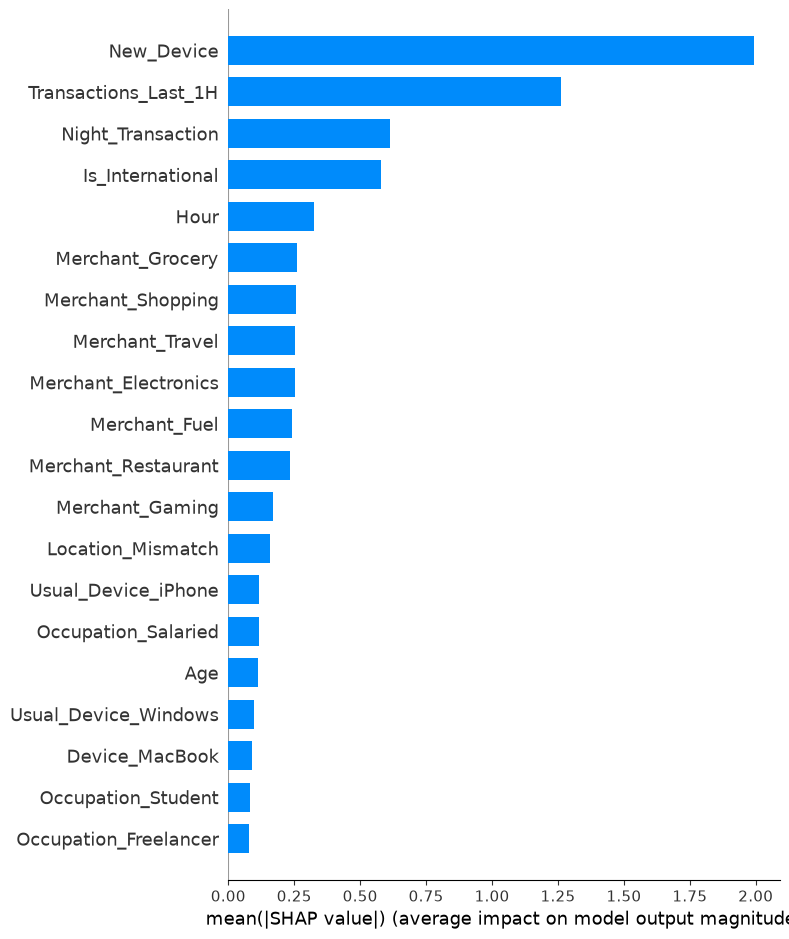

In [58]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar"
)

In [59]:
import joblib

joblib.dump(xgb_model, "fraud_detection_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


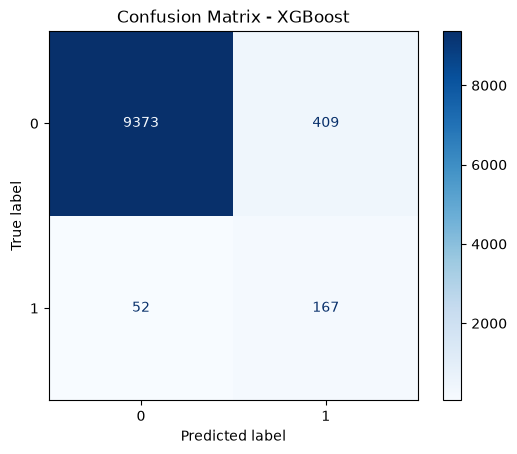

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_30,   # Threshold 0.3 wala final prediction
    cmap="Blues"
)

plt.title("Confusion Matrix - XGBoost")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

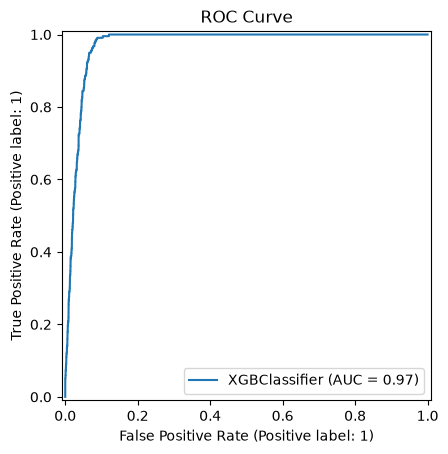

In [61]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

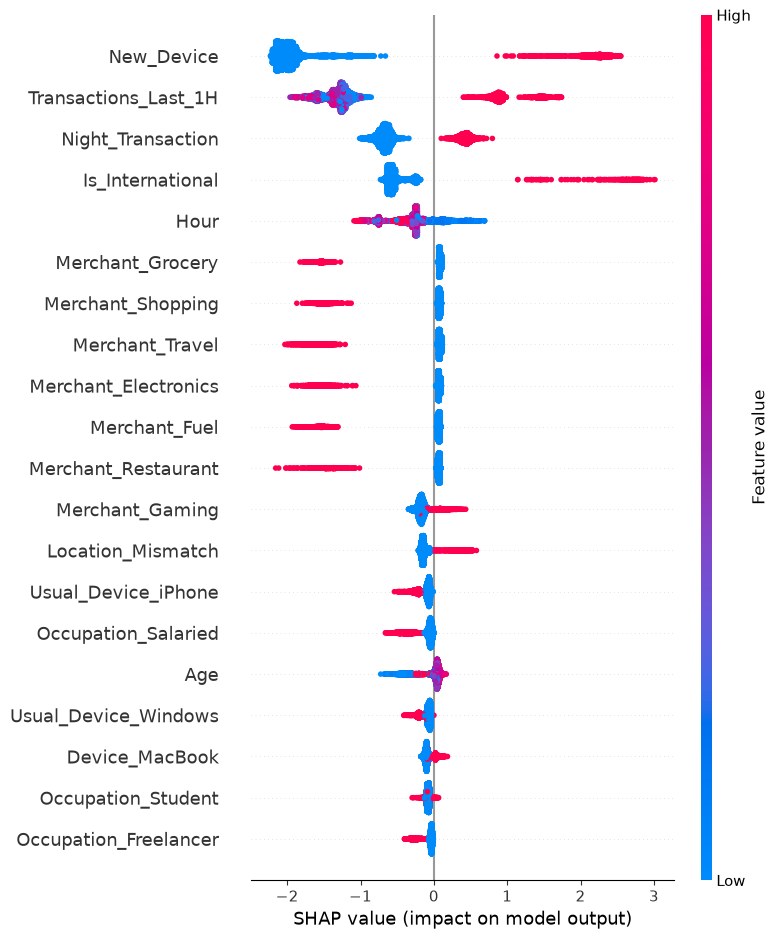

In [62]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    show=False
)

plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

In [63]:
print(X.columns.tolist())

['Amount', 'Hour', 'Is_International', 'Transactions_Last_1H', 'Age', 'Monthly_Income', 'Average_Transaction', 'Transaction_Ratio', 'New_Device', 'Location_Mismatch', 'Night_Transaction', 'Location_Bengaluru', 'Location_Chennai', 'Location_Delhi', 'Location_Dubai', 'Location_Hyderabad', 'Location_Jaipur', 'Location_Kolkata', 'Location_London', 'Location_Lucknow', 'Location_Moscow', 'Location_Mumbai', 'Location_Pune', 'Location_Singapore', 'Device_MacBook', 'Device_Unknown', 'Device_Windows', 'Device_iPhone', 'Merchant_Electronics', 'Merchant_Fuel', 'Merchant_Gaming', 'Merchant_Grocery', 'Merchant_Restaurant', 'Merchant_Shopping', 'Merchant_Travel', 'Merchant_Unknown', 'Occupation_Freelancer', 'Occupation_Retired', 'Occupation_Salaried', 'Occupation_Student', 'Home_City_Bengaluru', 'Home_City_Chennai', 'Home_City_Delhi', 'Home_City_Hyderabad', 'Home_City_Jaipur', 'Home_City_Kolkata', 'Home_City_Lucknow', 'Home_City_Mumbai', 'Home_City_Pune', 'Usual_Device_MacBook', 'Usual_Device_Windows